# Artificial CoLA

In this notebook, we will use the synthetic actomyosin cortex (see [Artificial Cells](../notebooks/artificial_cells.ipynb)) to simulate a synthetic cortial laser ablation (CoLA) cut.

In [1]:
import numpy as np 
import os
import tifffile

Make sure to run `pip install -e .` before running the cell below. This command will make sure `diet4cola` is installed as a module in your current Python/Conda environment.

In [2]:
from diet4cola.generation.cola import CoLACut
from diet4cola.generation.masks import cell_mask
from diet4cola.generation.noise import myosin_noise, actin_noise
from diet4cola.generation.operations import add, mul, normalize

from diet4cola.utils import *

## Actomyosin Cortex

We first generate a simple synthetic actomyosin cortex.

In [3]:
seed = 42
width = 512
height = 512

np.random.seed(seed)
off_x = 256 + (np.random.randint(32) - 16)
off_y = 256 + (np.random.randint(32) - 16)

In [4]:
def generate_cell_layer() -> tuple[np.ndarray, tuple[int, int], float]:
    # Cell mask
    cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = cell_mask(width, height, (off_x, off_y), (200, 200), 50, seed)

    return (cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle)

def generate_actomyosin_cortex(cell_mask_layer: np.ndarray) -> np.ndarray:
    # Myosin layer
    myosin_layer        = myosin_noise(width, height, seed = seed, iterations=10)
    myosin_layer        = mul(myosin_layer, cell_mask_layer)

    # Actin layer
    actin_layer         = actin_noise(width, height, cell_mask_layer, 2560, -0.05, seed)
    actin_layer         = mul(actin_layer, cell_mask_layer)

    # Combine myosin and actin layers into actomyosin
    actomyosin_layer    = add(myosin_layer, actin_layer)
    actomyosin_layer    = normalize(actomyosin_layer)

    return actomyosin_layer

In [5]:
cell_mask_layer, (cell_extent_a, cell_extent_b), cell_angle = generate_cell_layer()

In [6]:
#actomyosin_layer = generate_actomyosin_cortex(cell_mask_layer)
#save_cortex(actomyosin_layer, './data/cortex_1')

In [7]:
actomyosin_layer = load_cortex('./data/cortex_1.npy')

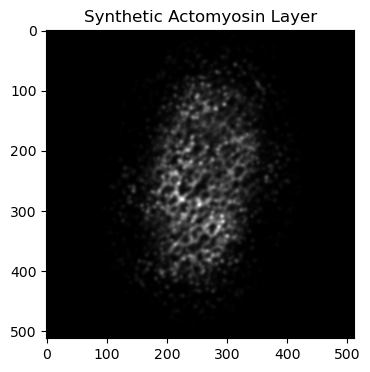

In [8]:
plot_2d_array(actomyosin_layer, 'Synthetic Actomyosin Layer')

## CoLA Cut

Next, we can create a new CoLA cut.

In [9]:
cola_cut = CoLACut((off_x, off_y), 32, 150, seed)

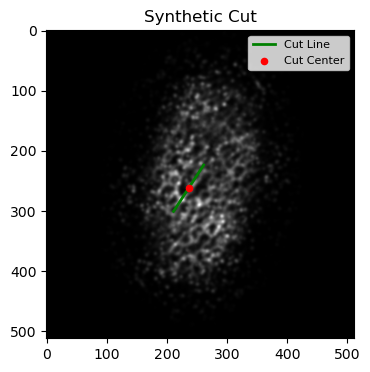

In [10]:
plot_synthetic_cut(actomyosin_layer, 
                   cola_cut.cut_center, 
                   cola_cut.cut_origin,
                   cola_cut.cut_destination)